In [ ]:
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import alpha
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from itertools import combinations
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,ConfusionMatrixDisplay,classification_report,r2_score
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, chi2, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR


fish_path = glob("../INPUT_FISH/Fish.csv")
# fish_path
fish_data_ = pd.read_csv(fish_path[0])
# fish_data_.shape
# fish_data_.isna().sum()
# fish_data_.Species.value_counts()
# fish_data_[fish_data_.Weight <= 0]
fish_data_ = fish_data_.dropna()
fish_data_df = fish_data_.drop([40])
le = LabelEncoder()

fish_data_df["Species_encoded"] = le.fit_transform(fish_data_df["Species"])
#
# dummy__ = pd.get_dummies(fish_data_df['Species'])
# fish_data_df_dummy = pd.concat([fish_data_df, dummy__], axis=1)
# fish_data_df_dummy = fish_data_df_dummy.drop('Species', axis=1)
fish_data_w_species = fish_data_df.drop(columns=['Species'])



linear_model = LinearRegression()

### SVR Preparation (Scaler)

In [ ]:
feats = ['Length1', 'Length2', 'Length3', 'Height', 'Width', 'Species_encoded']
targ = 'Weight'

X = fish_data_w_species[feats]
y = np.ravel(fish_data_w_species[targ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print('Taille train:', X_train.shape, 'Taille test:', X_test.shape)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


C_values = [0.01, 0.1, 1, 10, 100]
svr_results = []
for C in C_values:
    svr = LinearSVR(C=C, random_state=42)
    svr.fit(X_train_scaled, y_train)
    y_pred_svr = svr.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred_svr)
    svr_results.append({'C': C, 'r2': r2})

svr_df = pd.DataFrame(svr_results).sort_values('r2', ascending=False).reset_index(drop=True)
svr_df

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(svr_df['C'], svr_df['r2'], marker='o')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('R2 (test)')
plt.title('LinearSVR: influence du paramètre C')
plt.grid(True)
plt.show()

### Linear SVR with good value of C

In [ ]:
# svr = LinearSVR(C=100, random_state=42)
# svr.fit(X_train_scaled, y_train)
# y_pred_svr = svr.predict(X_test_scaled)
# r2 = r2_score(y_test, y_pred_svr)
# print({'C': 100, 'r2': r2})

In [ ]:
best_C = svr_df.loc[svr_df['r2'].idxmax(), 'C']
print('Meilleur C:', best_C)

best_svr = LinearSVR(C=best_C, random_state=42)
best_svr.fit(X_train_scaled, y_train)
y_pred_best_svr = best_svr.predict(X_test_scaled)
print('R2 (best LinearSVR):', r2_score(y_test, y_pred_best_svr))

### Plot test & prediction

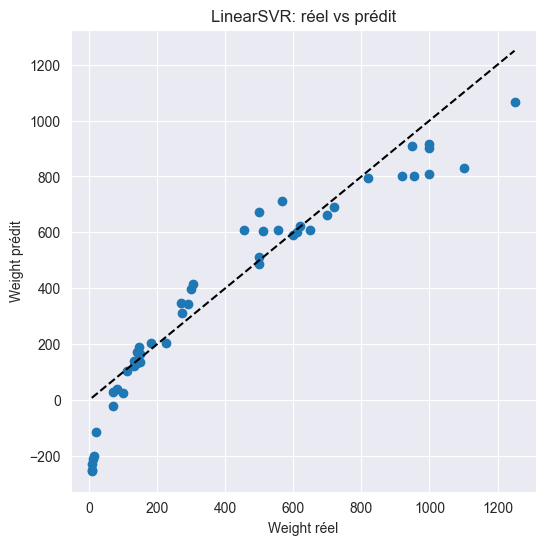

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best_svr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Weight réel')
plt.ylabel('Weight prédit')
plt.title('LinearSVR: réel vs prédit')
plt.grid(True)
plt.show()